In [6]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
import sys
sys.path.append("..")
from dpa.dpa_fit import DPA
import dpa.dpa_fit as fit
import importlib
import json

In [7]:
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [8]:
import torch
import xarray as xr

def torch_to_dataarray(x_tensor, coords_ds, lat_dim=32, lon_dim=32, name="variable"):
    """
    Convert a flattened 2D torch tensor to a 3D xarray.DataArray (lat, lon, time).

    Parameters:
    ----------
    x_tensor : torch.Tensor
        A 2D tensor of shape (time_steps, lat_dim * lon_dim), or a 1D tensor to be reshaped.
    lat_dim : int
        Number of latitude points.
    lon_dim : int
        Number of longitude points.
    coords_ds : xarray.Dataset
        Dataset containing 'lat', 'lon', and 'time' coordinates to assign.
    name : str, optional
        Name of the variable in the DataArray.

    Returns:
    -------
    xarray.DataArray
        The reshaped and labeled data as an xarray.DataArray.
    """
    # Step 1: Convert to NumPy
    data_np = x_tensor.detach().cpu().numpy()

    # Step 2: Determine time_steps and reshape
    time_steps = data_np.shape[0]
    data_np = data_np.reshape(time_steps, lat_dim, lon_dim)

    # Step 3: Transpose to (lat, lon, time)
    data_np = data_np.transpose(1, 2, 0)

    # Step 4: Create the DataArray
    da = xr.DataArray(
        data_np,
        dims=("lat", "lon", "time"),
        coords={
            "lat": coords_ds.lat,
            "lon": coords_ds.lon,
            "time": coords_ds.time
        },
        name=name
    )

    return da


In [12]:
# First, transpose to (time, lat, lon) if needed
def data_to_torch(ds, variable):
    temp_data = ds[variable]
    data = temp_data.transpose('time', 'lat', 'lon')
    
    # Now convert to numpy
    data_np = data.values  # Shape: (time, lat, lon)
    
    # Flatten lat and lon together
    time_steps, lat_dim, lon_dim = data_np.shape
    data_np = data_np.reshape(time_steps, lat_dim * lon_dim)
    
    
    data_np = data_np  # Shape: (grid_cell, timestep)
    
    # Finally, convert to torch tensor
    data_tensor = torch.tensor(data_np, dtype=torch.float32)
    print(data_tensor.shape)
    return data_tensor



def predictors_to_torch(ds, variable):
    temp_data = ds[variable]
    data = temp_data.transpose('time', 'mode')
    
    # Now convert to numpy
    data_np = data.values  # Shape: (time, lat, lon)

    
    # Flatten lat and lon together
    #time_steps, lat_dim, lon_dim = data_np.shape
    #data_np = data_np.reshape(time_steps, lat_dim * lon_dim)
    
    
    #data_np = data_np  # Shape: (grid_cell, timestep)
    
    # Finally, convert to torch tensor
    data_tensor = torch.tensor(data_np, dtype=torch.float32)
    print(data_tensor.shape)
    return data_tensor

In [10]:
# read contents from the settings.json file
settings_file_path = 'dpa_train_settings.json'

with open(settings_file_path, 'r') as file:
    settings = json.load(file)

In [13]:
# load my temperature data
# Load your NetCDF file
ds = xr.open_dataset(settings['dataset_trefht'])

ds_train = ds.isel(time=slice(0, 4769 * 80))
ds_test = ds.isel(time=slice(4769 * 80, 476900))

# transform to torch tensors
x_tr = data_to_torch(ds_train, "TREFHT")
x_te = data_to_torch(ds_test, "TREFHT")

# load Z500
ds_z500 = xr.open_dataset(settings['dataset_z500'])
z500 = predictors_to_torch(ds_z500, "pseudo_pcs")
z500_train = z500[:381520,:]
z500_test = z500[381520:,:]

# initilize model
dpa = fit.DPA(data_dim=1024,
              latent_dims=settings['latent_dims'],
              num_layer=settings['num_layer'],
              hidden_dim=settings['hidden_dim'],
              device=device,
              joint = True)

torch.Size([381520, 1024])
torch.Size([95380, 1024])
torch.Size([476900, 1000])
GPU is available, running on GPU.



In [ ]:
# load my temperature data
# Load your NetCDF file
ds = xr.open_dataset("/work/fl53wumy-llaae_data_new/fl53wumy-llaae_data_new-1748049607/llaae_data/Europe_subset_TREFHT_CESM2_LE_5daily_JJA/stacked_TREFHT_JJA.nc")
ds
ds_train = ds.isel(time=slice(0, 4769 * 80))
ds_test = ds.isel(time=slice(4769 * 80, 0))
#ds_train
x_tr = data_to_torch(ds_train, variable="TREFHT")
x_te = data_to_torch(ds_test, variable="TREFHT")

slp_tr = predictors_to_torch(ds_train)
slp_te = predictors_to_torch(ds_test).to(device)

In [14]:
# when using GPU
# Path to the saved model file
model_path = "/work/fl53wumy-llaae_data_new/fl53wumy-llaae_data_new-1748049607/dpa_output/dpa_training_output_jointDPA_20250617_184157/model_1000.pt"

# Load the state dict from the .pt file
state_dict = torch.load(model_path)

# Load the state dict into the internal DPA model
dpa.model.load_state_dict(state_dict)

<All keys matched successfully>

In [6]:
# when using cpu
import torch

# Path to the saved model file
model_path = "saved_models/model_30.pt"  # ← fixed missing slash too

# Load the state dict on CPU
state_dict = torch.load(model_path, map_location=torch.device('cpu'))

# Load the state dict into the internal DPA model
dpa.model.load_state_dict(state_dict)


<All keys matched successfully>

In [15]:
# check what parameters the models has
dpa.check_parameters()

encoder.input_layer.layer1.0.weight torch.Size([100, 1024])
encoder.input_layer.layer1.0.bias torch.Size([100])
encoder.input_layer.layer2.weight torch.Size([100, 100])
encoder.input_layer.layer2.bias torch.Size([100])
encoder.input_layer.layer3.weight torch.Size([100, 1024])
encoder.input_layer.layer3.bias torch.Size([100])
encoder.inter_layer.0.layer1.0.weight torch.Size([100, 100])
encoder.inter_layer.0.layer1.0.bias torch.Size([100])
encoder.inter_layer.0.layer2.weight torch.Size([100, 100])
encoder.inter_layer.0.layer2.bias torch.Size([100])
encoder.out_layer.layer1.0.weight torch.Size([100, 100])
encoder.out_layer.layer1.0.bias torch.Size([100])
encoder.out_layer.layer2.weight torch.Size([100, 100])
encoder.out_layer.layer2.bias torch.Size([100])
decoder.input_layer.layer1.0.weight torch.Size([100, 200])
decoder.input_layer.layer1.0.bias torch.Size([100])
decoder.input_layer.layer2.weight torch.Size([100, 200])
decoder.input_layer.layer2.bias torch.Size([100])
decoder.inter_layer

In [9]:
for name, param in dpa.model.named_parameters():
    if param.requires_grad:
        print(f"{name}: {param.shape}")


encoder.input_layer.layer1.0.weight: torch.Size([500, 1024])
encoder.input_layer.layer1.0.bias: torch.Size([500])
encoder.input_layer.layer2.weight: torch.Size([500, 500])
encoder.input_layer.layer2.bias: torch.Size([500])
encoder.input_layer.layer3.weight: torch.Size([500, 1024])
encoder.input_layer.layer3.bias: torch.Size([500])
encoder.out_layer.layer1.0.weight: torch.Size([500, 500])
encoder.out_layer.layer1.0.bias: torch.Size([500])
encoder.out_layer.layer2.weight: torch.Size([10, 500])
encoder.out_layer.layer2.bias: torch.Size([10])
encoder.out_layer.layer3.weight: torch.Size([10, 500])
encoder.out_layer.layer3.bias: torch.Size([10])
decoder.input_layer.layer1.0.weight: torch.Size([500, 110])
decoder.input_layer.layer1.0.bias: torch.Size([500])
decoder.input_layer.layer2.weight: torch.Size([500, 600])
decoder.input_layer.layer2.bias: torch.Size([500])
decoder.input_layer.layer3.weight: torch.Size([500, 10])
decoder.input_layer.layer3.bias: torch.Size([500])
decoder.out_layer.laye

In [16]:
# Assume you still know lat_dim and lon_dim
# (You saved these when you flattened earlier!)
lat_dim, lon_dim = 32, 32
time_steps = 36144
# Step 1: (optional if needed) Move from torch to numpy
data_np_reverted = x_re.numpy()

# Step 2: Reshape to (time_steps, lat_dim, lon_dim)
data_np_reverted = data_np_reverted.reshape(time_steps, lat_dim, lon_dim)

# Step 3: Transpose to (lat_dim, lon_dim, time_steps)
data_np_reverted = data_np_reverted.transpose(1, 2, 0)  # Now (lat, lon, time)

print(data_np_reverted.shape) 

# Create the DataArray
reconstructed_da = xr.DataArray(
    data_np_reverted,
    dims=("lat", "lon", "time"),
    coords={
        "lat": ds_test.lat,
        "lon": ds_test.lon,
        "time": ds_test.time
    },
    name="Temperature"  # You can name the variable
)

reconstructed_da

(32, 32, 36144)


<xarray.DataArray 'Temperature' (lat: 32, lon: 32, time: 36144)> Size: 148MB
array([[[-0.08056071,  0.5573886 ,  0.52256966, ...,  1.9201496 ,
          2.3604665 ,  2.0576437 ],
        [-0.5980703 ,  0.55942696,  0.29156202, ...,  2.0695887 ,
          2.0647905 ,  2.3460448 ],
        [-0.27659044,  0.4901035 ,  0.2529811 , ...,  2.5434117 ,
          2.1348126 ,  2.7294927 ],
        ...,
        [ 2.093732  , -0.53213745,  0.57975006, ...,  1.4006836 ,
          3.7567062 ,  3.2837844 ],
        [ 2.182991  , -0.3444587 ,  1.0152732 , ...,  1.3757985 ,
          3.9002266 ,  2.951169  ],
        [ 1.9748486 , -0.2527487 ,  0.92914444, ...,  1.3744526 ,
          3.3850188 ,  3.3155773 ]],

       [[-0.12704198,  0.50564325,  0.8752091 , ...,  2.0314598 ,
          1.8166337 ,  2.70203   ],
        [-0.87712866,  0.4982701 ,  0.67719734, ...,  2.5203116 ,
          2.277089  ,  1.8492638 ],
        [-0.8137337 ,  0.45536372,  0.8283187 , ...,  2.8161497 ,
          1.9021894 ,  2.897656  ],
...
        [ 6.682767  ,  6.1547146 , -2.291201  , ...,  4.5474577 ,
          1.8074179 ,  4.862871  ],
        [ 7.361116  ,  5.5763865 , -1.4458554 , ...,  4.3962717 ,
          2.263114  ,  4.9524302 ],
        [ 7.6811547 ,  6.342538  , -1.8609171 , ...,  4.867118  ,
          2.8598638 ,  5.626646  ]],

       [[-0.6541205 ,  0.55088556,  0.06848712, ..., -1.4615009 ,
         -1.6873473 ,  1.4628754 ],
        [-1.169048  ,  0.16015404, -0.04523081, ..., -1.649684  ,
         -1.3688778 ,  1.0361629 ],
        [-0.9958082 ,  0.47785336,  0.03999744, ..., -1.4684838 ,
         -0.75966203,  1.1281335 ],
        ...,
        [ 7.3318253 ,  5.789975  , -1.1390141 , ...,  4.5725384 ,
          2.2029092 ,  5.336804  ],
        [ 7.8916693 ,  6.2289796 , -1.9436624 , ...,  5.125376  ,
          1.9031942 ,  5.553703  ],
        [ 8.173058  ,  5.7980123 , -1.234169  , ...,  4.560428  ,
          2.17537   ,  5.4222193 ]]], shape=(32, 32, 36144), dtype=float32)
Coordinates:
  * lat      (lat) float64 256B 34.4 35.34 36.28 37.23 ... 61.73 62.67 63.61
  * lon      (lon) float64 256B -11.25 -10.0 -8.75 -7.5 ... 25.0 26.25 27.5
  * time     (time) object 289kB 1850-01-16 00:00:00 ... 2100-12-16 00:00:00

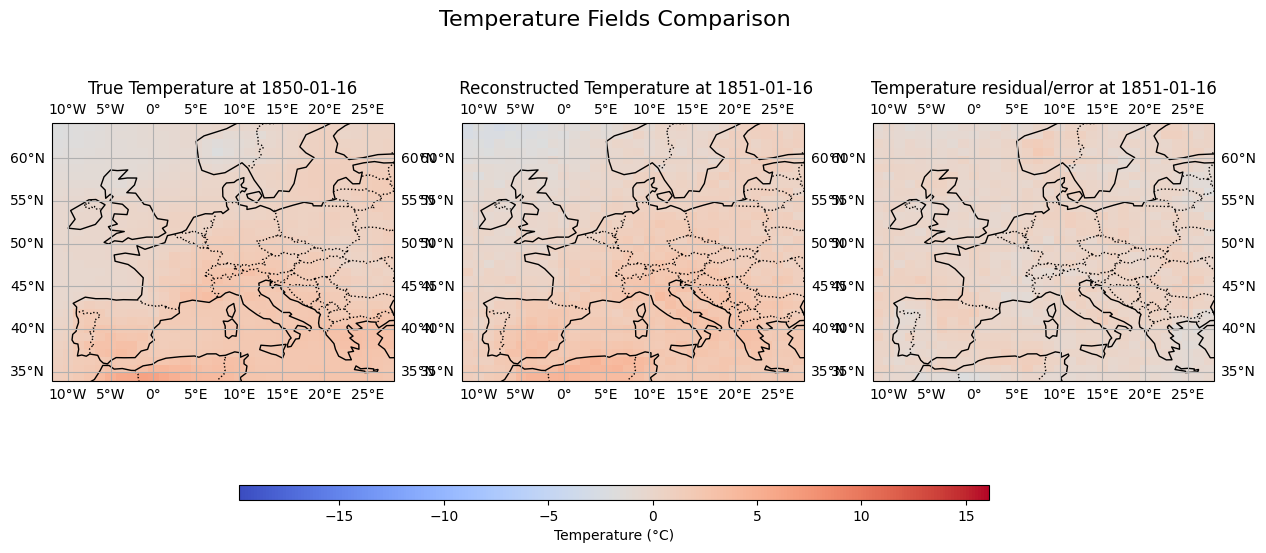

<xarray.DataArray 'Temperature' (lat: 32, lon: 32)> Size: 8kB
array([[ 0.02012706,  0.51995242,  0.36368382, ...,  0.64705133,
         0.56891847,  0.41172445],
       [-0.41864586, -0.44340324,  0.24845767, ...,  0.88952732,
         0.48092794,  0.64109445],
       [-0.18926752,  0.2972821 ,  0.72947037, ...,  0.98633838,
         0.65580428,  0.14359713],
       ...,
       [-0.00955749,  0.19443536,  0.68611813, ..., -0.5264554 ,
        -0.21508348, -0.41334581],
       [ 0.69813633,  0.38584328,  0.6501646 , ..., -0.60575438,
         0.22800958, -0.29517347],
       [ 0.9238925 ,  0.17176306,  0.69945812, ..., -0.09191573,
         0.05644792, -0.34535372]], shape=(32, 32))
Coordinates:
  * lat      (lat) float64 256B 34.4 35.34 36.28 37.23 ... 61.73 62.67 63.61
  * lon      (lon) float64 256B -11.25 -10.0 -8.75 -7.5 ... 25.0 26.25 27.5
    time     object 8B 2061-04-15 12:00:00

In [48]:
# Select a single timestep to plot
timestep = 10000
reconstruction_to_plot = reconstructed_da.isel(time=timestep)  
test_truth_to_plot = ds_test.Temperature.isel(time=timestep)

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr

# Example: Load data (you should already have your `reconstructed_da`)
# reconstructed_da = xr.open_dataset('your_file.nc')['Temperature']

# Prepare figure with 2 subplots
fig, axs = plt.subplots(1, 3, figsize=(15, 5), subplot_kw={'projection': ccrs.PlateCarree()})

# Flatten axs in case it's a 2D array
if isinstance(axs, np.ndarray):
    axs = axs.flatten()


# Set common color limits across both plots
vmin = reconstructed_da.min().item()
vmax = reconstructed_da.max().item()

# Plot on first panel
p1 = test_truth_to_plot.plot(
    ax=axs[0],
    transform=ccrs.PlateCarree(),
    cmap='coolwarm',
    vmin=vmin,
    vmax=vmax,
    add_colorbar=False  # Important! No individual colorbars
)
axs[0].set_title(f"True Temperature at {str(time1.values)[:10]}")
axs[0].coastlines(resolution='110m', linewidth=1)
axs[0].add_feature(cfeature.BORDERS, linestyle=':')
axs[0].add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
axs[0].gridlines(draw_labels=True)

#####################################################################
# Plot on second panel
p2 = reconstruction_to_plot.plot(
    ax=axs[1],
    transform=ccrs.PlateCarree(),
    cmap='coolwarm',
    vmin=vmin,
    vmax=vmax,
    add_colorbar=False  # Important!
)
axs[1].set_title(f" Reconstructed Temperature at {str(time2.values)[:10]}")
axs[1].coastlines(resolution='110m', linewidth=1)
axs[1].add_feature(cfeature.BORDERS, linestyle=':')
axs[1].add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
axs[1].gridlines(draw_labels=True)

#####################################################################
# Plot on third panel
p3 = (reconstruction_to_plot - test_truth_to_plot).plot(
    ax=axs[2],
    transform=ccrs.PlateCarree(),
    cmap='coolwarm',
    vmin=vmin,
    vmax=vmax,
    add_colorbar=False  # Important!
)
axs[2].set_title(f"Temperature residual/error at {str(time2.values)[:10]}")
axs[2].coastlines(resolution='110m', linewidth=1)
axs[2].add_feature(cfeature.BORDERS, linestyle=':')
axs[2].add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
axs[2].gridlines(draw_labels=True)

# ===========================
# Here's the important fix:
# Create a new axes for the colorbar
cbar_ax = fig.add_axes([0.25, 0.0, 0.5, 0.03])  
# [left, bottom, width, height] in figure coordinates (0 to 1)

cbar = fig.colorbar(p2, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Temperature (°C)')
# ===========================

# Add an overall figure title
fig.suptitle('Temperature Fields Comparison', fontsize=16)

#plt.tight_layout()
plt.show()

test_truth_to_plot - reconstruction_to_plot

In [22]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def plot_temperature_panel(ax, dataarray, vmax_shared, sample_nr=None, title=""):
    """
    Plot a single temperature panel on a given axis with Cartopy.

    Parameters:
    ----------
    ax : matplotlib.axes._subplots.AxesSubplot
        Axis on which to plot.
    dataarray : xarray.DataArray
        The temperature data to plot.
    title : str
        Title for the subplot.
    vmax_shared : float
        Symmetric max value for colormap scaling (vmin = -vmax).
    """
    levels = np.linspace(-5, 5, 11)

    p = dataarray.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap='coolwarm',
        vmin=-vmax_shared,
        vmax=vmax_shared,
        levels=levels,
        add_colorbar=False
    )
    ax.set_title(title)
    ax.coastlines(resolution='110m', linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
    #ax.gridlines(draw_labels=False)
    if sample_nr is not None:
        ax.text(
            x=0, y=0.5,                # left edge, center vertically
            s=sample_nr,          # your annotation text
            transform=ax.transAxes,   # interpret x/y in axis coordinates (0–1)
            rotation=90,              # rotate to align with y-axis
            va='center', ha='right',  # vertical/horizontal alignment
            fontsize=12
        )
    return p


In [36]:
importlib.reload(fit)
latent_decode1 = dpa.predict_latent(x=z500_test.to(device), double=True)
latent_decode2 = dpa.predict_latent(x=z500_test.to(device), double=True)
latent_decode3 = dpa.predict_latent(x=z500_test.to(device), double=True)
# x1, x2, z1, z2 = latent_decode
print(len(latent_decode))
print(latent_decode[0].shape)

# Assuming:
# - x_re is a tensor of shape (time_steps, lat_dim * lon_dim)
# - ds_test is the reference dataset containing lat/lon/time

reconstructed_da_11 = torch_to_dataarray(latent_decode1[0], coords_ds=ds_test, name="Temperature")
reconstructed_da_12 = torch_to_dataarray(latent_decode1[1], coords_ds=ds_test, name="Temperature")
reconstructed_da_21 = torch_to_dataarray(latent_decode2[0], coords_ds=ds_test, name="Temperature")
reconstructed_da_22 = torch_to_dataarray(latent_decode2[1], coords_ds=ds_test, name="Temperature")
reconstructed_da_31 = torch_to_dataarray(latent_decode3[0], coords_ds=ds_test, name="Temperature")
reconstructed_da_32 = torch_to_dataarray(latent_decode3[1], coords_ds=ds_test, name="Temperature")

4
torch.Size([95380, 1024])


[<GeoAxes: > <GeoAxes: > <GeoAxes: > <GeoAxes: > <GeoAxes: > <GeoAxes: >
 <GeoAxes: > <GeoAxes: > <GeoAxes: > <GeoAxes: > <GeoAxes: > <GeoAxes: >
 <GeoAxes: > <GeoAxes: > <GeoAxes: > <GeoAxes: > <GeoAxes: > <GeoAxes: >
 <GeoAxes: > <GeoAxes: > <GeoAxes: > <GeoAxes: > <GeoAxes: > <GeoAxes: >
 <GeoAxes: > <GeoAxes: > <GeoAxes: > <GeoAxes: > <GeoAxes: > <GeoAxes: >
 <GeoAxes: > <GeoAxes: > <GeoAxes: > <GeoAxes: > <GeoAxes: >]
i: 0
i: 1
i: 2
i: 3
i: 4


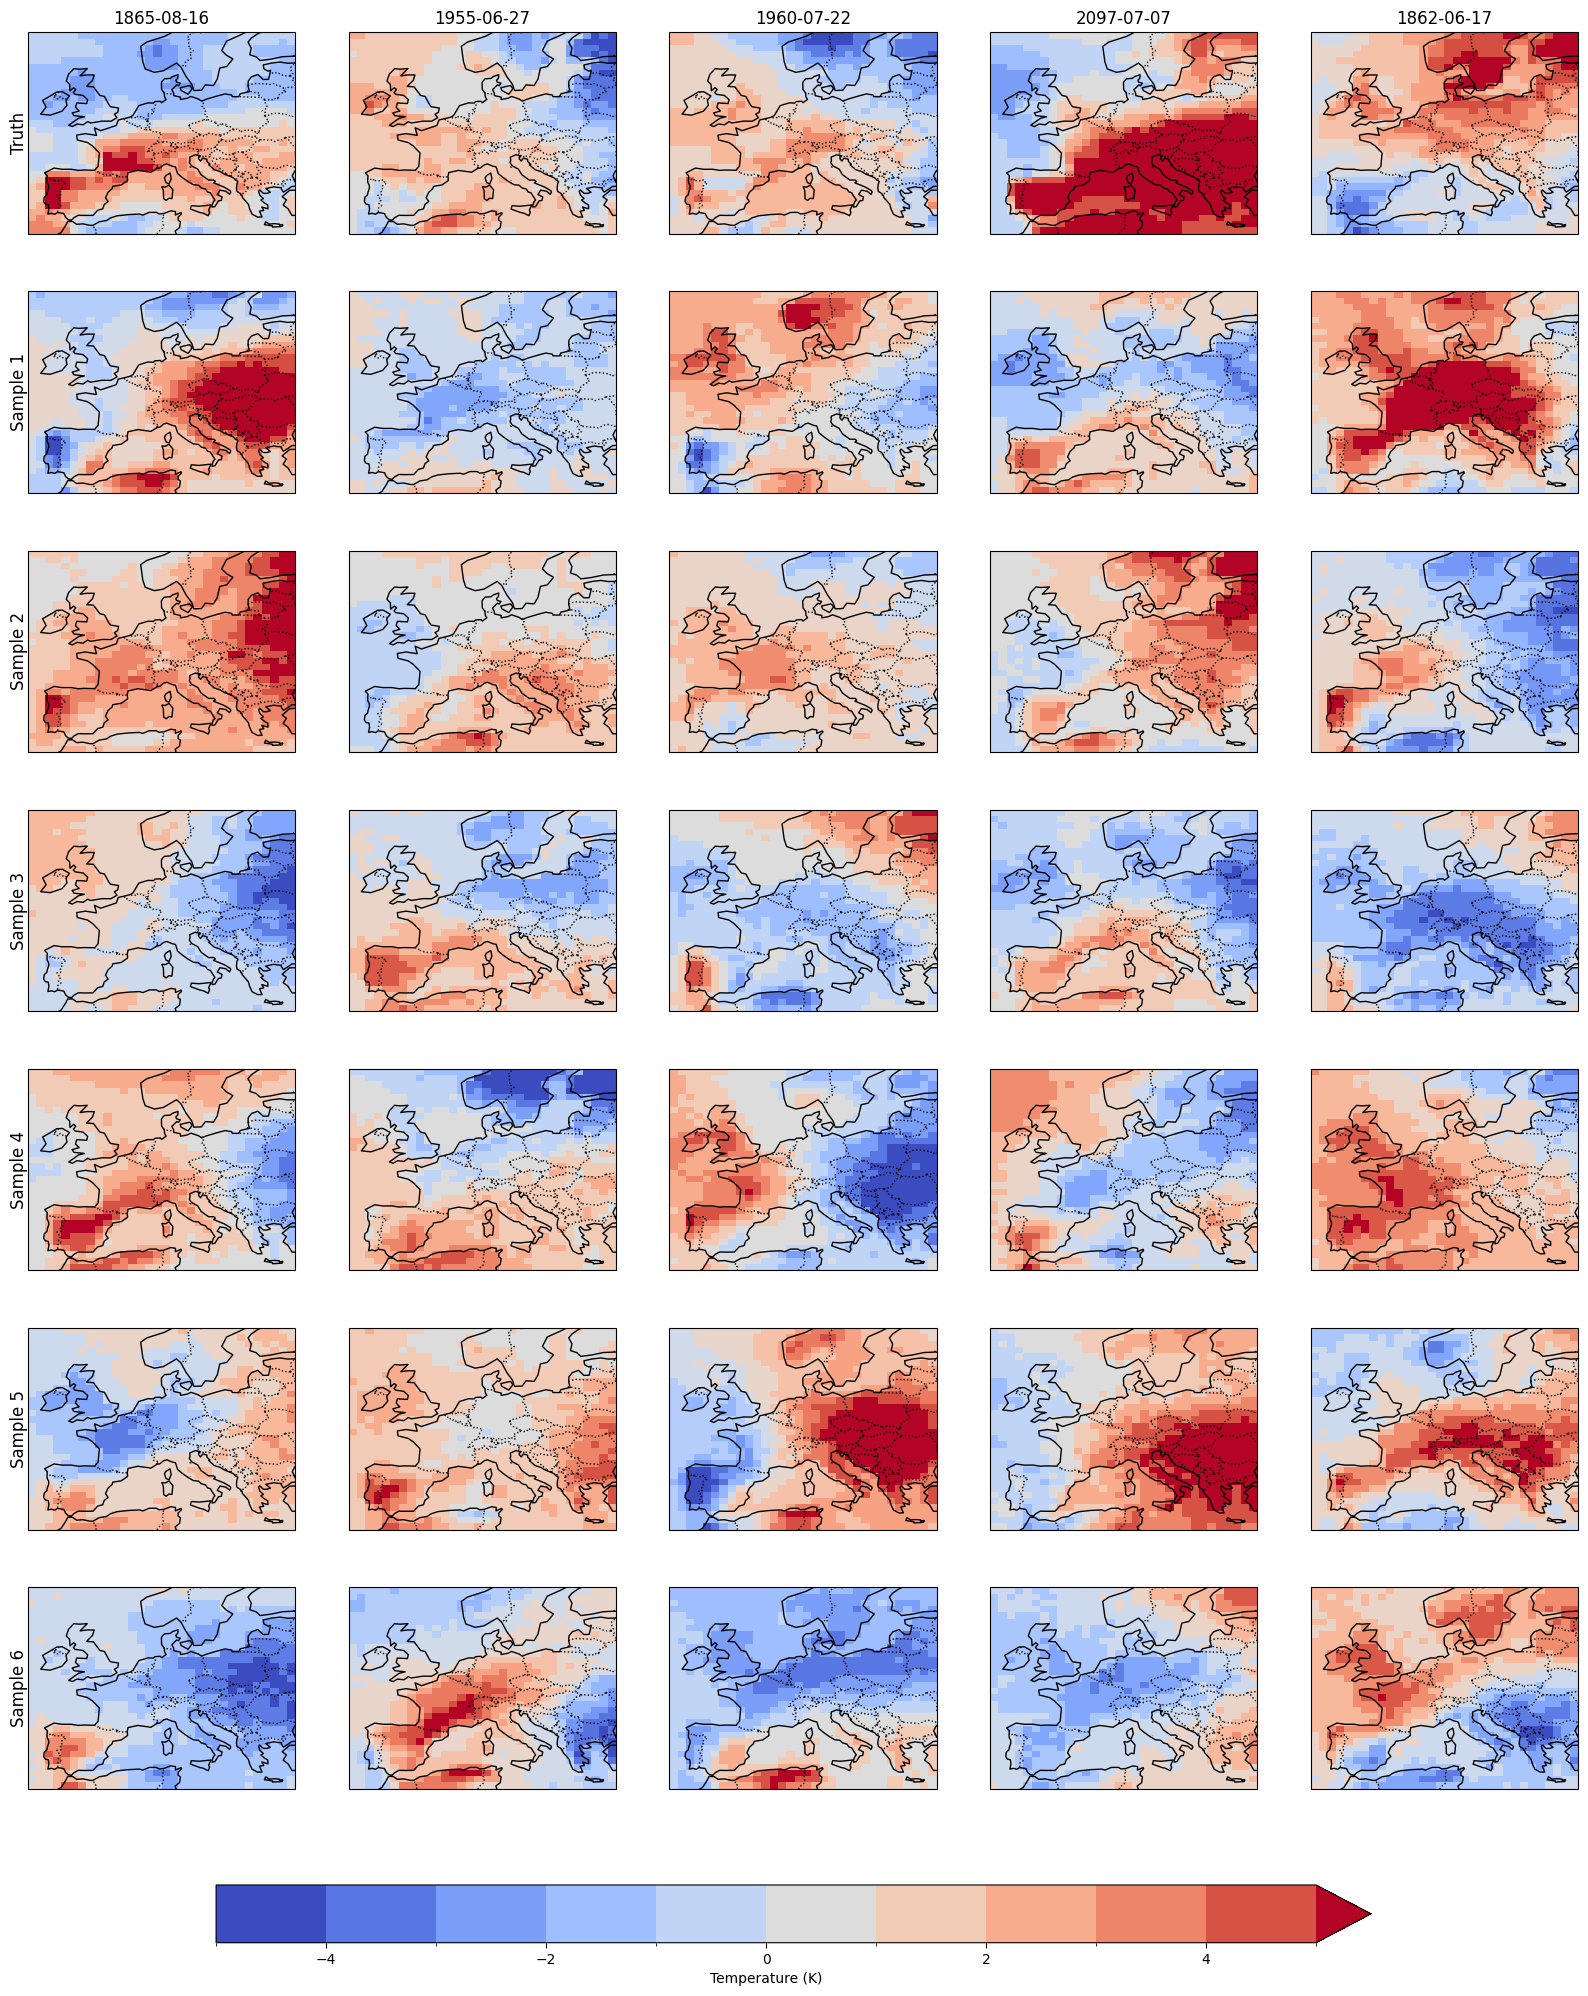

In [49]:
fig, axs = plt.subplots(nrows=7, ncols=5, figsize=(20, 25), subplot_kw={'projection': ccrs.PlateCarree()})
axs = axs.flatten()  # Flatten for easy indexing
print(axs)
list_of_dataarrays_re = [reconstructed_da_11, reconstructed_da_12, reconstructed_da_21, reconstructed_da_22, reconstructed_da_31, reconstructed_da_32,]
timesteps=[300,2000,2100,4700,5000]
for i, (ax, t) in enumerate(zip(axs, timesteps)):
    title = f"{str(ds_test.isel(time=t).time.values)[:10]}"
    print("i:", i)
    if i ==0:
        plot_temperature_panel(axs[0], ds_test.TREFHT.isel(time=t), title = title, vmax_shared=5, sample_nr = "Truth")
        plot_temperature_panel(axs[5], list_of_dataarrays_re[0].isel(time=t), vmax_shared=5, sample_nr = "Sample 1")
        plot_temperature_panel(axs[10], list_of_dataarrays_re[1].isel(time=t), vmax_shared=5, sample_nr = "Sample 2")
        plot_temperature_panel(axs[15], list_of_dataarrays_re[2].isel(time=t), vmax_shared=5, sample_nr = "Sample 3")
        plot_temperature_panel(axs[20], list_of_dataarrays_re[3].isel(time=t), vmax_shared=5, sample_nr = "Sample 4")
        plot_temperature_panel(axs[25], list_of_dataarrays_re[4].isel(time=t), vmax_shared=5, sample_nr = "Sample 5")
        plot_temperature_panel(axs[30], list_of_dataarrays_re[5].isel(time=t), vmax_shared=5, sample_nr = "Sample 6")
        
    else:
        plot_temperature_panel(ax, ds_test.TREFHT.isel(time=t), title = title, vmax_shared=5)
        plot_temperature_panel(axs[i+5], list_of_dataarrays_re[0].isel(time=t), vmax_shared=5)
        plot_temperature_panel(axs[i+10], list_of_dataarrays_re[1].isel(time=t), vmax_shared=5)
        plot_temperature_panel(axs[i+15], list_of_dataarrays_re[2].isel(time=t), vmax_shared=5)
        plot_temperature_panel(axs[i+20], list_of_dataarrays_re[3].isel(time=t), vmax_shared=5)
        plot_temperature_panel(axs[i+25], list_of_dataarrays_re[4].isel(time=t), vmax_shared=5)
        plot_temperature_panel(axs[i+30], list_of_dataarrays_re[5].isel(time=t), vmax_shared=5)
        




# Optional: Add a colorbar
cbar = fig.colorbar(axs[0].collections[0], ax=axs, orientation='horizontal', fraction=0.03, pad=0.05)
cbar.set_label('Temperature (K)')

#plt.tight_layout()
plt.savefig("/home/sc.uni-leipzig.de/fl53wumy/llaae_new/Model_trials/first_joint_training/1000_epochs_training_prediction_samples.pdf", format='pdf')
plt.show()

In [ ]:
# Temperature-Verteilung in einer grid-cell ?

In [25]:
import re
import numpy as np
import matplotlib.pyplot as plt

def parse_log_file(log_file_path):
    """
    Parse the .log file to extract training and testing losses.

    Args:
        log_file_path (str): Path to the .log file.

    Returns:
        dict: A dictionary containing train and test losses over epochs.
    """
    train_losses = []
    test_losses = []
    with open(log_file_path, 'r') as file:
        for line in file:
            # Match train loss lines
            train_match = re.match(r"\[Epoch \d+\] (.+)", line)
            if train_match:
                train_losses.append([float(x.strip()) for x in train_match.group(1).split(",")])

            # Match test loss lines
            test_match = re.match(r"\(test\)\s+(.+)", line)
            if test_match:
                test_losses.append([float(x.strip()) for x in test_match.group(1).split(",")])

    return {
        "train": np.array(train_losses),
        "test": np.array(test_losses),
    }

def plot_loss_evolution(loss_data, k_levels=None, save_path=None):
    """
    Plot the loss evolution over epochs for selected `k` levels during training and testing.

    Args:
        loss_data (dict): A dictionary containing train and test losses over epochs.
        k_levels (list, optional): List of `k` levels to plot. Defaults to all available levels.
        save_path (str, optional): Path to save the plot. If None, the plot is displayed.
    """
    train_losses = loss_data['train']
    test_losses = loss_data['test']

    if k_levels is None:
        k_levels = range(train_losses.shape[1])  # Default to all levels

    epochs = np.arange(1, len(train_losses) + 1)

    plt.figure(figsize=(12, 6))
    for k in k_levels:
        if k < train_losses.shape[1]:  # Ensure k is valid
            plt.plot(epochs, train_losses[:, k], label=f"Train Loss Level {k}")
            if len(test_losses) > 0:
                plt.plot(epochs, test_losses[:, k], '--', label=f"Test Loss Level {k}")
        else:
            print(f"Warning: k level {k} is out of bounds and will be ignored.")

    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Loss Evolution Over Epochs")
    plt.legend()
    plt.grid()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    else:
        plt.show()



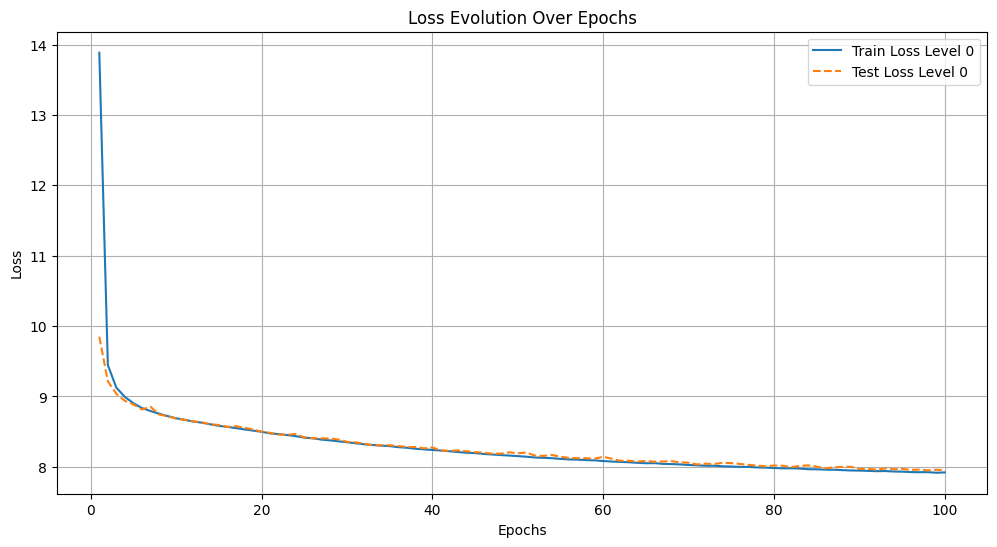

In [31]:
# Example usage
log_file_path = "saved_models/log.txt"  # Replace with the path to your .log file
loss_data = parse_log_file(log_file_path)

# Specify the `k` levels you want to plot, or set to `None` to plot all levels
k_levels_to_plot = [0]  # Example: Plot only levels 0 and 2
plot_loss_evolution(loss_data, k_levels=k_levels_to_plot, save_path="loss_evolution_k_levels.png")  # Replace with None to display the plot

In [23]:
loss_data['train'].shape

(44, 11)